## 1. Setup

In [ ]:
import os
import json
import shutil
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from scipy.stats import randint, uniform
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold,
    cross_val_score, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE     = 42
DATA_PATH        = "/content/drive/MyDrive/UMKMentor_Datasets/tokopedia_products_with_review.csv"
MODEL_DIR        = "/content/model_artifact"
TRAIN_CATEGORIES = [
    "elektronik", "hiburan", "olahraga", "kecantikan",
    "makanan_minuman", "fashion", "pertukangan",
]
EXTRA_DATA_PATHS = [
    "/content/drive/MyDrive/UMKMentor_Datasets/synthetic_pertukangan_800.csv",
    "/content/synthetic_pertukangan_800.csv",
]

os.makedirs(MODEL_DIR, exist_ok=True)

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print("Drive mount dilewati:", exc)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Helper functions

In [ ]:
def parse_numeric(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).replace("None", None),
        errors="coerce",
    )

def to_binary(series):
    return (
        series.astype(str).str.lower()
        .map({"true": 1, "1": 1, "yes": 1})
        .fillna(0).astype(int)
    )

def get_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

def load_raw_data(primary_path, extra_paths=None):
    """Load data dan tag kolom 'source' per file untuk EDA."""
    frames, loaded = [], []

    if primary_path and Path(primary_path).exists():
        df_main = pd.read_csv(primary_path)
        df_main["source"] = "asli"
        frames.append(df_main)
        loaded.append(str(primary_path))
    else:
        raise FileNotFoundError(f"File utama tidak ditemukan: {primary_path}")

    for extra_path in extra_paths or []:
        if not extra_path:
            continue
        if Path(extra_path).exists():
            df_extra = pd.read_csv(extra_path)
            df_extra["source"] = Path(extra_path).stem
            frames.append(df_extra)
            loaded.append(str(extra_path))
        else:
            print(f"File tambahan tidak ditemukan, dilewati: {extra_path}")

    df_out = pd.concat(frames, ignore_index=True)
    print("Sumber data yang dimuat:")
    for src in loaded:
        print(f"  - {src}")
    return df_out

def safe_percentile_rank(x, sorted_values):
    sorted_values = np.asarray(sorted_values, dtype=float)
    if sorted_values.size == 0 or pd.isna(x):
        return 0.5
    return float(
        np.searchsorted(sorted_values, float(x), side="right") / len(sorted_values)
    )

## 2. Memuat Data

In [ ]:
df_raw = load_raw_data(DATA_PATH, EXTRA_DATA_PATHS)

File tambahan tidak ditemukan, dilewati: /content/synthetic_pertukangan_800.csv
Sumber data yang dimuat:
  - /content/drive/MyDrive/UMKMentor_Datasets/tokopedia_products_with_review.csv
  - /content/drive/MyDrive/UMKMentor_Datasets/synthetic_pertukangan_800.csv


## 3. EDA (Exploratory Data Analysis)

In [ ]:
df_raw.head()

,product_id,category,name,count_sold,discounted_price,preorder,price,stock,gold_merchant,is_official,...,review_id,variant_name,message,review_rating,review_time,review_timestamp,review_response,review_like,bad_rating_reason,source
0,268823794,rumah_tangga|storage_fair,Ambalan Laci Melayang 60x20x5.5 MERK KINBAR A543,2112.0,NaN,0,108500,295,1,0,...,"['1587995048', '1572236924', '1330433454', '11...","['', '', '', '', '', '', '', '', '', '', '', '...","['goodboy', 'Produk telah diterima dalam keada...","[5, 5, 5, 5, 5, 1, 3, 5, 5, 5, 5, 5, 5, 5, 5, ...","['1753321151', '1752470614', '1742575219', '17...","['4 bulan lalu', '4 bulan lalu', '8 bulan lalu...",['Terima kasih telah berbelanja di Mega-Persad...,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...","['', '', '', '', '', 'Kendala: Tidak lengkap/s...",asli
1,2145556006,rumah_tangga|storage_fair,Daiso Storage Box with Lid -,285.0,NaN,0,33000,1,1,1,...,"['1548475223', '1329468255', '1302218079', '12...","['', '', '', '', '', '', '', '', '', '', '', '...",['Lucu kotak nya. Bahan juga kokoh.Terima kasi...,"[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","['1751300951', '1742542078', '1741368517', '17...","['5 bulan lalu', '8 bulan lalu', '8 bulan lalu...",['Terima kasih telah berbelanja di Daiso Japan...,"[0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 1]","['', '', '', '', '', '', '', '', '', '', '', '...",asli
2,1276550898,rumah_tangga|storage_fair,Shinpo 204 Kotak Box Tempat Masker Pensil Peny...,3686.0,NaN,0,9300,6853,1,0,...,"['1773985424', '1204731599', '1146722203', '10...","['', '', '', '', '', '', '', '', '', '', '', '...","['', 'alhmdulillah 25pcs telah meluncur sampai...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1, ...","['1763542549', '1739817200', '1737818855', '17...","['1 minggu lalu', '9 bulan lalu', '10 bulan la...",['Terima kasih telah berbelanja di MiracleStar...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","['', '', '', '', '', '', '', '', '', '', '', '...",asli
3,781949458,rumah_tangga|storage_fair,Informa 42X20X79 cm Rak Sepatu 5 Tingkat - Hit...,5354.0,128600.0,0,59400,26,1,1,...,"['1757598767', '1716814172', '1716301825', '17...","['', 'Default', 'Default', '', '', '', '', '',...","['ringkih sih tampaknya, waktu masang juga cop...","[5, 1, 5, 5, 1, 5, 5, 4, 5, 2, 5, 5, 4, 4, 5, ...","['1762660562', '1760226451', '1760179929', '17...","['2 minggu lalu', '1 bulan lalu', '1 bulan lal...","['Hai Kak, terima kasih ulasan dan rating yang...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","['', '', '', '', '', '', '', '', '', 'Kendala:...",asli
4,9665251383,rumah_tangga|storage_fair,STORA LACI PENYIMPANAN STACKABLE - BIRU TUA,97.0,32300.0,0,21700,3,1,1,...,"['1138204360', '1032453018', '1003087492', '98...","['', '', '', '']","['mantap punya, apalagi dapet pas diskon', 'Ma...","[5, 5, 5, 5]","['1735829546', '1714130551', '1708143944', '17...","['11 bulan lalu', 'Lebih dari 1 tahun lalu', '...",['Terima kasih telah berbelanja di toko kami. ...,"[0, 0, 0, 0]","['', '', '', '']",asli


In [ ]:
df_raw.shape

(6353, 26)

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6353 entries, 0 to 6352
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         6353 non-null   int64  
 1   category           6353 non-null   object 
 2   name               6353 non-null   object 
 3   count_sold         5543 non-null   float64
 4   discounted_price   1772 non-null   float64
 5   preorder           6353 non-null   int64  
 6   price              6353 non-null   int64  
 7   stock              6353 non-null   int64  
 8   gold_merchant      6353 non-null   int64  
 9   is_official        6353 non-null   int64  
 10  is_topads          6353 non-null   int64  
 11  rating_average     6287 non-null   float64
 12  shop_id            5553 non-null   float64
 13  shop_location      6326 non-null   object 
 14  warehouse_id       4759 non-null   float64
 15  product_url        5553 non-null   object 
 16  review_id          5553 

In [ ]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
product_id,6353.0,2.722768e+14,2.170011e+16,1826616.0,1.959876e+09,9.000000e+09,1.555191e+10,1.729623e+18
count_sold,5543.0,7.095232e+03,5.257515e+04,1.0,6.000000e+00,4.000000e+01,7.000000e+02,2.691306e+06
discounted_price,1772.0,7.563427e+05,2.133365e+06,750.0,6.724025e+04,1.650000e+05,4.701750e+05,2.819800e+07
preorder,6353.0,4.722178e-03,6.856106e-02,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
price,6353.0,1.050426e+06,3.220410e+06,275.0,4.937000e+04,1.349000e+05,4.750000e+05,4.999900e+07
stock,6353.0,5.491923e+03,6.680669e+04,1.0,5.000000e+00,3.100000e+01,2.400000e+02,3.099969e+06
gold_merchant,6353.0,8.074925e-01,3.943004e-01,0.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
is_official,6353.0,6.518180e-01,4.764315e-01,0.0,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
is_topads,6353.0,7.870297e-03,8.837186e-02,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
rating_average,6287.0,4.947320e+00,1.014313e-01,3.0,4.900000e+00,5.000000e+00,5.000000e+00,5.000000e+00


In [ ]:
# Missing values
miss = df_raw.isnull().sum()
miss_df = (
    miss.to_frame("count")
    .assign(pct=(miss / len(df_raw) * 100).round(2))
    .sort_values("count", ascending=False)
)
print("\nMissing values per kolom:")
print(miss_df.to_string())


Missing values per kolom:
                   count    pct
discounted_price    4581  72.11
warehouse_id        1594  25.09
count_sold           810  12.75
message              800  12.59
review_time          800  12.59
review_rating        800  12.59
review_id            800  12.59
product_url          800  12.59
shop_id              800  12.59
variant_name         800  12.59
review_response      800  12.59
review_like          800  12.59
bad_rating_reason    800  12.59
review_timestamp     800  12.59
rating_average        66   1.04
shop_location         27   0.42
product_id             0   0.00
category               0   0.00
is_official            0   0.00
gold_merchant          0   0.00
stock                  0   0.00
price                  0   0.00
preorder               0   0.00
name                   0   0.00
is_topads              0   0.00
source                 0   0.00


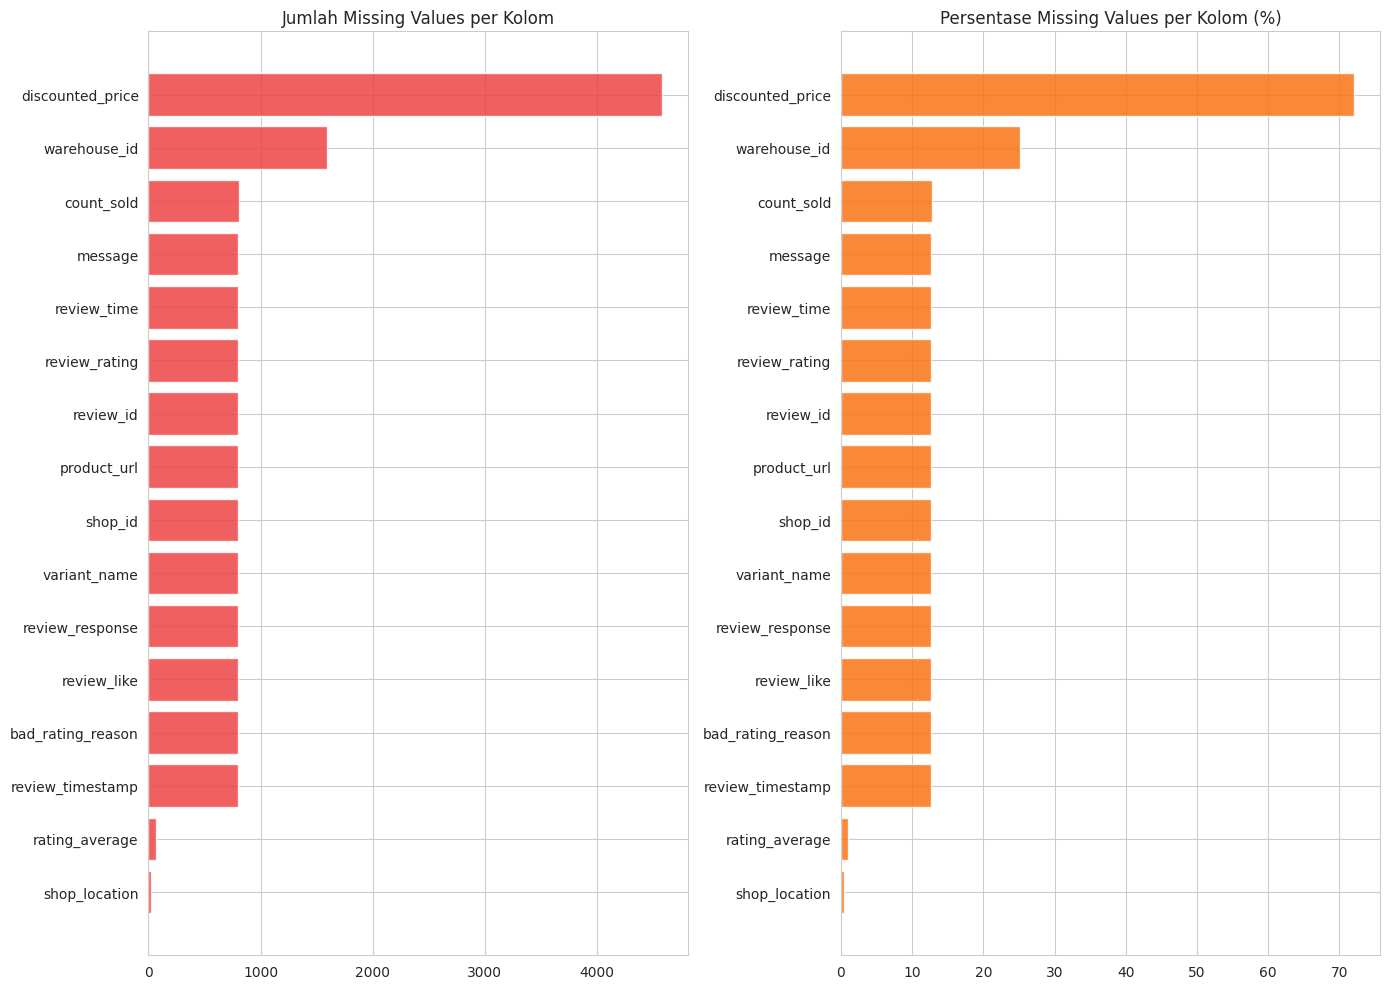

In [ ]:
miss_nonzero = miss_df[miss_df["count"] > 0]
if len(miss_nonzero) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(miss_nonzero) * 0.5 + 2)))
    axes[0].barh(miss_nonzero.index[::-1], miss_nonzero["count"][::-1],
                 edgecolor="white", alpha=0.85, color="#ef4444")
    axes[0].set_title("Jumlah Missing Values per Kolom")
    axes[1].barh(miss_nonzero.index[::-1], miss_nonzero["pct"][::-1],
                 edgecolor="white", alpha=0.85, color="#f97316")
    axes[1].set_title("Persentase Missing Values per Kolom (%)")
    plt.tight_layout(); plt.show()

In [ ]:
# Distribusi count_sold per sumber
print("\nDistribusi count_sold per sumber:")
print(df_raw.groupby("source")["count_sold"].describe().to_string())


Distribusi count_sold per sumber:
                            count         mean           std  min    25%   50%     75%        max
source                                                                                           
asli                       4743.0  8254.270926  56754.415454  1.0   6.00  38.0  1098.5  2691306.0
synthetic_pertukangan_800   800.0   223.581250    766.131224  1.0  13.75  48.0   149.0    15092.0


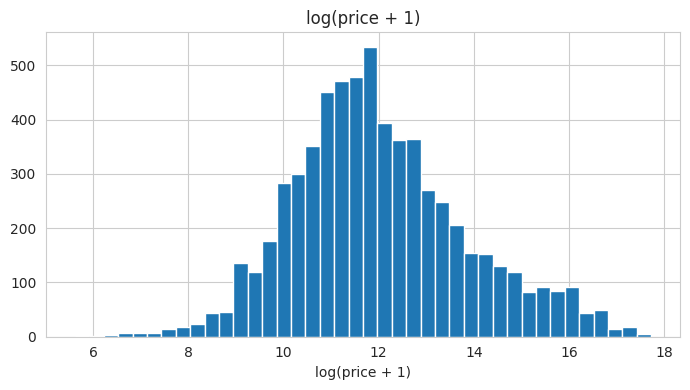

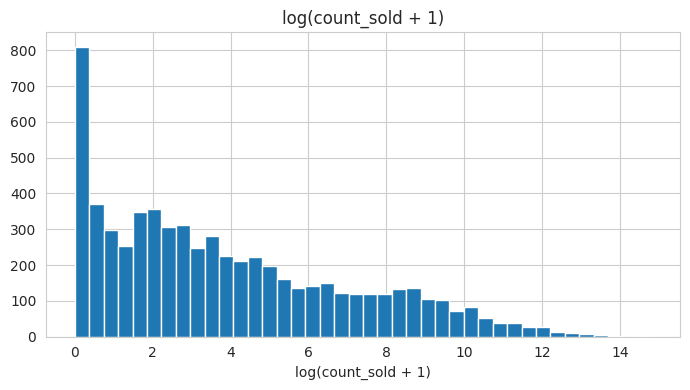

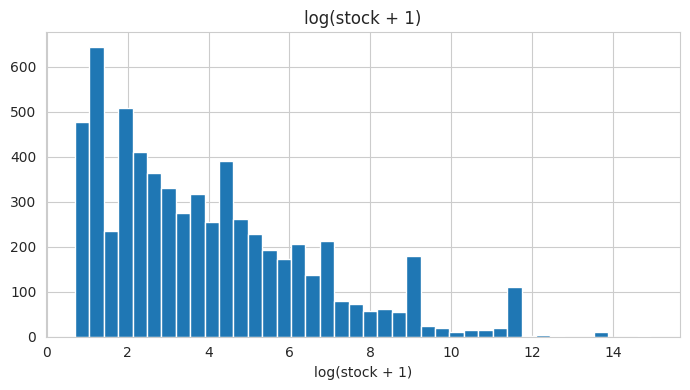

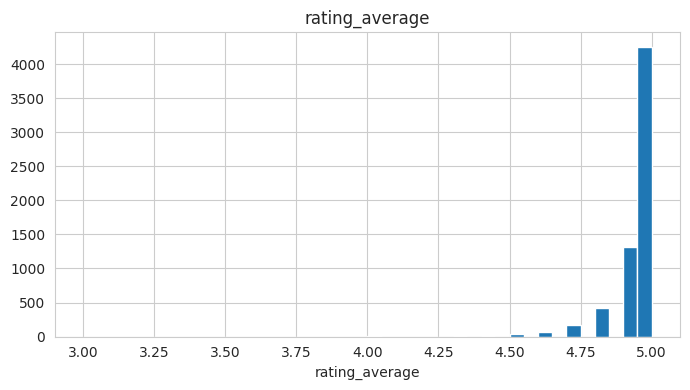

In [ ]:
# Distribusi numerik utama
for col, title in [
    ("price",          "log(price + 1)"),
    ("count_sold",     "log(count_sold + 1)"),
    ("stock",          "log(stock + 1)"),
    ("rating_average", "rating_average"),
]:
    fig, ax = plt.subplots(figsize=(7, 4))
    vals = (parse_numeric(df_raw[col]).fillna(0)
            if col != "rating_average"
            else parse_numeric(df_raw[col]).dropna())
    ax.hist(np.log1p(vals) if col != "rating_average" else vals,
            bins=40, edgecolor="white")
    ax.set_title(title); ax.set_xlabel(title)
    plt.tight_layout(); plt.show()

In [ ]:
# Distribusi kategori
raw_main = df_raw["category"].astype(str).str.split("|").str[0].str.strip().str.lower()
print("\nKategori utama mentah:")
print(raw_main.value_counts().to_string())


Kategori utama mentah:
category
pertukangan          800
rumah_tangga         482
perawatan_tubuh      389
elektronik           382
office_stationery    381
buku                 356
dapur                329
makanan_minuman      324
kecantikan           317
handphone_tablet     300
film_musik           298
perawatan_hewan      290
gaming               287
fashion_anak         270
otomotif             266
komputer_laptop      260
olahraga             236
kesehatan            189
kamera                69
ibu_bayi              61
fashion_muslim        37
                      27
fashion_pria           3


In [ ]:
# Seleksi kolom
USECOLS = [
    "product_id", "category", "name", "count_sold",
    "discounted_price", "preorder", "price", "stock",
    "gold_merchant", "is_official", "is_topads",
    "rating_average", "shop_location", "source",
]
df_raw = df_raw[[c for c in USECOLS if c in df_raw.columns]].copy()
df_raw = df_raw.rename(columns={"category": "category_raw", "name": "product_name"})
print(f"\nShape setelah seleksi kolom : {df_raw.shape}")



Shape setelah seleksi kolom : (6353, 14)


## 4. PEMBERSIHAN DATA

In [ ]:
df = df_raw.copy()

for col in ["price", "discounted_price", "count_sold", "stock", "rating_average"]:
    df[col] = parse_numeric(df[col])

for col in ["gold_merchant", "is_official", "is_topads", "preorder"]:
    df[col] = to_binary(df[col])

df["category_main"] = (
    df["category_raw"].astype(str).str.split("|").str[0]
    .str.strip().str.lower()
    .replace({"": np.nan, "none": np.nan, "nan": np.nan})
)
df = df[df["category_main"].notna()].copy()

CAT_MAP = {
    "fashion_anak":    "fashion",
    "fashion_pria":    "fashion",
    "fashion_muslim":  "fashion",
    "gaming":          "hiburan",
    "film_musik":      "hiburan",
    "buku":            "hiburan",
    "elektronik":      "elektronik",
    "olahraga":        "olahraga",
    "kecantikan":      "kecantikan",
    "makanan_minuman": "makanan_minuman",
    "fashion":         "fashion",
    "hiburan":         "hiburan",
    "pertukangan":     "pertukangan",
}
df["category_main"] = df["category_main"].map(CAT_MAP).fillna(df["category_main"])
df = df[df["category_main"].isin(TRAIN_CATEGORIES)].copy()

before_dup    = len(df)
df            = df.drop_duplicates(subset="product_id", keep="first").copy()
dup_removed   = before_dup - len(df)

before_price  = len(df)
df            = df[df["price"].notna() & (df["price"] > 0)].copy()
price_removed = before_price - len(df)

before_sold   = len(df)
df            = df[df["count_sold"].notna()].copy()
sold_removed  = before_sold - len(df)

df["stock"]          = df["stock"].fillna(0)
df["rating_average"] = df["rating_average"].clip(1, 5).fillna(df["rating_average"].median())
df["is_jakarta"]     = (
    df["shop_location"].astype(str).str.lower()
    .str.contains("jakarta", na=False).astype(int)
)
df = df.reset_index(drop=True)

print("Ringkasan cleaning")
print(f"  Baris akhir                 : {len(df):,}")
print(f"  Duplikat product_id dihapus : {dup_removed:,}")
print(f"  Harga invalid dihapus       : {price_removed:,}")
print(f"  Baris tanpa count_sold      : {sold_removed:,}")
print(f"\nDistribusi kategori:\n{df['category_main'].value_counts().to_string()}")

Ringkasan cleaning
  Baris akhir                 : 3,039
  Duplikat product_id dihapus : 31
  Harga invalid dihapus       : 0
  Baris tanpa count_sold      : 240

Distribusi kategori:
category_main
hiburan            825
pertukangan        800
elektronik         375
makanan_minuman    323
kecantikan         250
fashion            236
olahraga           230


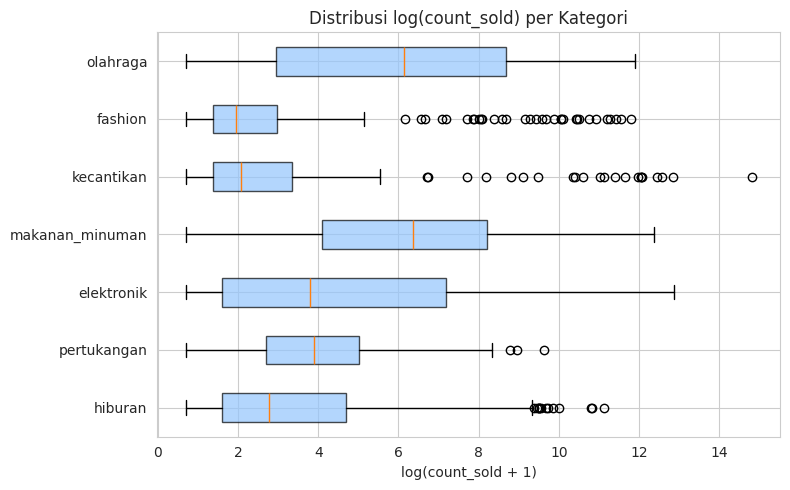

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
cat_order  = df["category_main"].value_counts().sort_values(ascending=False).index.tolist()
sold_data  = [np.log1p(df[df["category_main"] == c]["count_sold"].values) for c in cat_order]
bp = ax.boxplot(sold_data, vert=False, patch_artist=True, labels=cat_order)
for patch in bp["boxes"]:
    patch.set_facecolor("#93c5fd"); patch.set_alpha(0.7)
ax.set_title("Distribusi log(count_sold) per Kategori")
ax.set_xlabel("log(count_sold + 1)")
plt.tight_layout(); plt.show()

## 5. SPLIT DATA & FEATURE ENGINEERING

In [ ]:
df["row_id"] = np.arange(len(df))

train_ids, test_ids = train_test_split(
    df["row_id"], test_size=0.2,
    random_state=RANDOM_STATE, stratify=df["category_main"],
)
train_mask = df["row_id"].isin(train_ids)
test_mask  = df["row_id"].isin(test_ids)

print(f"Train : {train_mask.sum():,} baris | Test: {test_mask.sum():,} baris")

Train : 2,431 baris | Test: 608 baris


In [ ]:
# Statistik kategori dari train only
cat_stats = (
    df.loc[train_mask]
    .groupby("category_main")
    .agg(
        cat_median_price  = ("price",       "median"),
        cat_stock_median  = ("stock",       "median"),
        cat_pct_official  = ("is_official", "mean"),
        cat_sold_median   = ("count_sold",  "median"),
        cat_product_count = ("product_id",  "count"),
    )
    .reset_index()
)

df = df.merge(cat_stats, on="category_main", how="left")

GLOBAL_FALLBACK = {
    "cat_median_price":  float(cat_stats["cat_median_price"].median()),
    "cat_stock_median":  float(cat_stats["cat_stock_median"].median()),
    "cat_pct_official":  float(cat_stats["cat_pct_official"].median()),
    "cat_sold_median":   float(cat_stats["cat_sold_median"].median()),
    "cat_product_count": float(cat_stats["cat_product_count"].median()),
}

In [ ]:
# Label: above-median category sales = laku
df["is_laku"] = (df["count_sold"] > df["cat_sold_median"]).astype(int)

print("\nDistribusi label:")
vc = df["is_laku"].value_counts().sort_index()
print(f"  Tidak Laku (0): {vc.get(0,0):,} ({vc.get(0,0)/len(df):.1%})")
print(f"  Laku       (1): {vc.get(1,0):,} ({vc.get(1,0)/len(df):.1%})")


Distribusi label:
  Tidak Laku (0): 1,540 (50.7%)
  Laku       (1): 1,499 (49.3%)


In [ ]:
# Fitur harga
df["log_price"]         = np.log1p(df["price"])
df["log_price_vs_cat"]  = np.log1p(df["price"] / (df["cat_median_price"] + 1.0))
df["price_diff_median"] = df["log_price"] - np.log1p(df["cat_median_price"])

In [ ]:
# Cache nilai train per kategori untuk percentile rank saat inferensi
CATEGORY_TRAIN_VALUES = {
    col: {
        cat: np.sort(
            df.loc[train_mask & (df["category_main"] == cat), col]
            .dropna().astype(float).values
        )
        for cat in TRAIN_CATEGORIES
    }
    for col in ["price", "stock"]
}

In [ ]:
# Percentile rank
for feat, col in [("price_rank_in_cat", "price"), ("stock_rank_in_cat", "stock")]:
    df.loc[train_mask, feat] = (
        df.loc[train_mask].groupby("category_main")[col].rank(pct=True)
    )
    for cat in TRAIN_CATEGORIES:
        te = test_mask & (df["category_main"] == cat)
        if te.any():
            train_vals = CATEGORY_TRAIN_VALUES[col][cat]
            if len(train_vals) > 0:
                df.loc[te, feat] = (
                    np.searchsorted(train_vals, df.loc[te, col].values, side="right")
                    / len(train_vals)
                )
            else:
                df.loc[te, feat] = 0.5
    df[feat] = df[feat].fillna(0.5)

In [ ]:
# Fitur stok
df["stock_is_enough"]   = (df["stock"] > df["cat_stock_median"]).astype(int)
df["stock_price_ratio"] = np.log1p(df["stock"]) / (df["log_price"] + 1.0)

In [ ]:
# Fitur diskon — sinyal bisnis terkuat (#1 di feature importance)
df["has_discount"] = df["discounted_price"].notna().astype(int)
df["discount_pct"] = np.where(
    df["discounted_price"].notna() & (df["price"] > 0),
    (df["price"] - df["discounted_price"]) / df["price"],
    0.0,
)

In [ ]:
# Trust & lokasi
df["trust_factor"] = df["is_official"] + df["is_jakarta"]

In [ ]:
# One-hot kategori
df = pd.concat([df, pd.get_dummies(df["category_main"], prefix="cat", dtype=int)], axis=1)

In [ ]:
FEATURE_COLS = [
    "log_price",
    "log_price_vs_cat",
    "price_rank_in_cat",
    "price_diff_median",
    "rating_average",
    "has_discount",
    "discount_pct",
    "stock_rank_in_cat",
    "stock_is_enough",
    "stock_price_ratio",
    "is_topads",
    "is_jakarta",
    "trust_factor",
    "cat_median_price",
    "cat_stock_median",
    "cat_pct_official",
] + [f"cat_{c}" for c in TRAIN_CATEGORIES]

# Deduplikasi kolom
seen = set()
FEATURE_COLS = [f for f in FEATURE_COLS if not (f in seen or seen.add(f))]

X = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median(numeric_only=True))
y = df["is_laku"]
X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

print(f"\nFeature Engineering selesai.")
print(f"Total fitur : {len(FEATURE_COLS)}")
print(f"X_train     : {X_train.shape} | X_test: {X_test.shape}")


Feature Engineering selesai.
Total fitur : 23
X_train     : (2431, 23) | X_test: (608, 23)


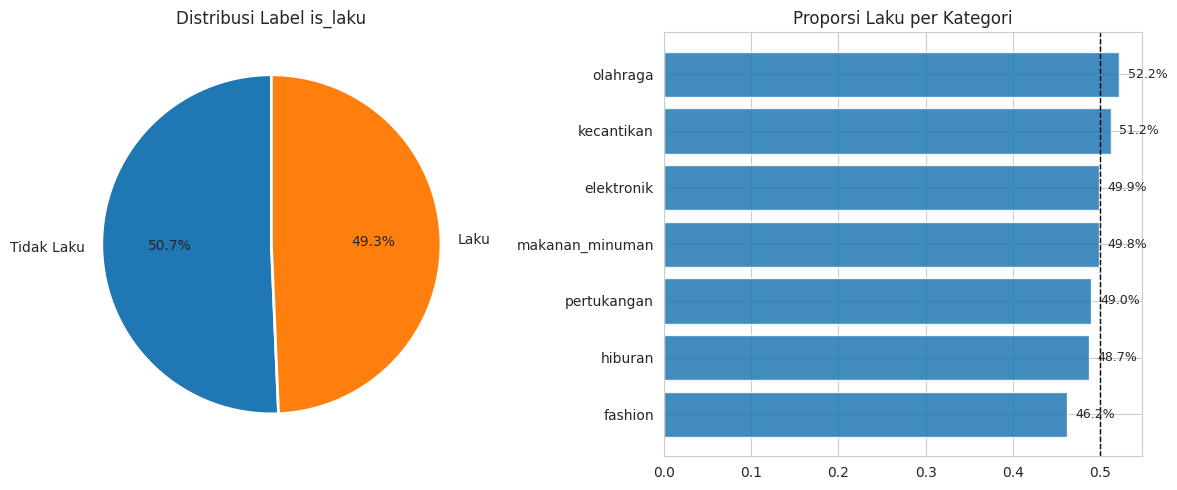

In [ ]:
# Visualisasi label & proporsi laku
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vc = df["is_laku"].value_counts().sort_index()
axes[0].pie(
    [vc.get(0, 0), vc.get(1, 0)], labels=["Tidak Laku", "Laku"],
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[0].set_title("Distribusi Label is_laku")

laku_rate = df.groupby("category_main")["is_laku"].mean().sort_values()
axes[1].barh(laku_rate.index, laku_rate.values, edgecolor="white", alpha=0.85)
axes[1].axvline(0.5, color="black", linestyle="--", lw=1)
axes[1].set_title("Proporsi Laku per Kategori")
for i, v in enumerate(laku_rate.values):
    axes[1].text(v + 0.01, i, f"{v:.1%}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

## 6. Baseline MODEL

In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    Xtr = X_tr.values if isinstance(X_tr, pd.DataFrame) else X_tr
    ytr = y_tr.values if isinstance(y_tr, pd.Series)    else y_tr
    Xte = X_te.values if isinstance(X_te, pd.DataFrame) else X_te
    yte = y_te.values if isinstance(y_te, pd.Series)    else y_te

    model.fit(Xtr, ytr)
    y_pred  = model.predict(Xte)
    y_score = get_score(model, Xte)

    acc = accuracy_score(yte, y_pred)
    f1  = f1_score(yte, y_pred, average="weighted")
    auc = roc_auc_score(yte, y_score)
    print(f"{name:<22} | Acc: {acc:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")
    return {
        "name": name, "model": model,
        "y_pred": y_pred, "y_score": y_score,
        "accuracy": acc, "f1_weighted": f1, "auc": auc,
    }

In [ ]:
rf_base  = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
gb_base  = GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)
xgb_base = XGBClassifier(
    n_estimators=250, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
)
lr_base  = Pipeline([("scaler", StandardScaler()),
                     ("clf", LogisticRegression(max_iter=4000, solver="liblinear"))])
svm_base = Pipeline([("scaler", StandardScaler()),
                     ("clf", LinearSVC(C=0.5, max_iter=4000))])

rf_res  = evaluate_model("Random Forest",       rf_base,  X_train, y_train, X_test, y_test)
gb_res  = evaluate_model("Gradient Boosting",   gb_base,  X_train, y_train, X_test, y_test)
xgb_res = evaluate_model("XGBoost",             xgb_base, X_train, y_train, X_test, y_test)
lr_res  = evaluate_model("Logistic Regression", lr_base,  X_train, y_train, X_test, y_test)
svm_res = evaluate_model("Linear SVM",          svm_base, X_train, y_train, X_test, y_test)

baseline_df = pd.DataFrame([
    {k: v for k, v in r.items() if k in ["name", "accuracy", "f1_weighted", "auc"]}
    for r in [rf_res, gb_res, xgb_res, lr_res, svm_res]
]).sort_values("auc", ascending=False)

print("\nRingkasan baseline:")
print(baseline_df.to_string(index=False))

Random Forest          | Acc: 0.663 | F1: 0.663 | AUC: 0.763
Gradient Boosting      | Acc: 0.671 | F1: 0.671 | AUC: 0.768
XGBoost                | Acc: 0.674 | F1: 0.674 | AUC: 0.770
Logistic Regression    | Acc: 0.643 | F1: 0.643 | AUC: 0.709
Linear SVM             | Acc: 0.640 | F1: 0.640 | AUC: 0.708

Ringkasan baseline:
               name  accuracy  f1_weighted      auc
            XGBoost  0.674342     0.674342 0.770044
  Gradient Boosting  0.671053     0.671124 0.767741
      Random Forest  0.662829     0.662697 0.762723
Logistic Regression  0.643092     0.642626 0.708563
         Linear SVM  0.639803     0.639661 0.708335


## 7. TUNING HYPERPARAMETER

In [ ]:
print("\nTuning Random Forest ...")
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions={
        "n_estimators":      randint(200, 400),
        "max_depth":         [4, 6, 8],
        "min_samples_split": randint(15, 30),
        "min_samples_leaf":  randint(8, 20),
        "class_weight":      ["balanced", None],
        "max_features":      uniform(0.6, 0.3),
    },
    n_iter=20, cv=cv_strat, scoring="roc_auc",
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
)
rs_rf.fit(X_train, y_train)
print(f"  Best CV AUC : {rs_rf.best_score_:.3f}")


Tuning Random Forest ...
  Best CV AUC : 0.792


In [ ]:
print("Tuning Gradient Boosting ...")
rs_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions={
        "n_estimators":      randint(150, 450),
        "max_depth":         randint(2, 4),
        "learning_rate":     uniform(0.02, 0.12),
        "subsample":         uniform(0.7, 0.2),
        "min_samples_split": randint(10, 25),
    },
    n_iter=20, cv=cv_strat, scoring="roc_auc",
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
)
rs_gb.fit(X_train, y_train)
print(f"  Best CV AUC : {rs_gb.best_score_:.3f}")

Tuning Gradient Boosting ...
  Best CV AUC : 0.797


In [ ]:
print("Tuning XGBoost ...")
rs_xgb = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    param_distributions={
        "n_estimators":     randint(150, 450),
        "max_depth":        randint(2, 4),
        "learning_rate":    uniform(0.02, 0.15),
        "subsample":        uniform(0.7, 0.2),
        "colsample_bytree": uniform(0.7, 0.2),
        "min_child_weight": randint(4, 12),
        "reg_alpha":        uniform(0.5, 1.5),
        "reg_lambda":       uniform(1.0, 3.0),
    },
    n_iter=20, cv=cv_strat, scoring="roc_auc",
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
)
rs_xgb.fit(X_train.values, y_train.values)
print(f"  Best CV AUC : {rs_xgb.best_score_:.3f}")

Tuning XGBoost ...
  Best CV AUC : 0.799


In [ ]:
rf_tuned  = rs_rf.best_estimator_
gb_tuned  = rs_gb.best_estimator_
xgb_tuned = rs_xgb.best_estimator_

# Tabel perbandingan baseline vs tuned
print("\n" + "=" * 60)
print("PERBANDINGAN BASELINE vs TUNED")
print("=" * 60)
print(f"{'Model':<22} {'Acc':>6} {'F1':>6} {'AUC':>6} {'Train Acc':>10} {'Gap':>6}")
print("  " + "-" * 56)

BEST_TABULAR_AUC   = 0
BEST_TABULAR_MODEL = None
BEST_TABULAR_NAME  = ""
BEST_TABULAR_PRED  = None
BEST_TABULAR_PROBA = None

candidates = {
    "RF Baseline":  (rf_base,  rf_res["y_pred"],  rf_res["y_score"]),
    "RF Tuned":     (rf_tuned,  None, None),
    "GB Baseline":  (gb_base,  gb_res["y_pred"],  gb_res["y_score"]),
    "GB Tuned":     (gb_tuned,  None, None),
    "XGB Baseline": (xgb_base, xgb_res["y_pred"], xgb_res["y_score"]),
    "XGB Tuned":    (xgb_tuned, None, None),
}

for name, (model, yp, ys) in candidates.items():
    if yp is None:
        yp = model.predict(X_test.values)
        ys = (model.predict_proba(X_test.values)[:, 1]
              if hasattr(model, "predict_proba")
              else model.decision_function(X_test.values))

    acc       = accuracy_score(y_test, yp)
    f1        = f1_score(y_test, yp, average="weighted")
    auc       = roc_auc_score(y_test, ys)
    train_acc = accuracy_score(y_train, model.predict(X_train.values))
    gap       = train_acc - acc
    flag      = "  (overfit)" if gap > 0.10 else ""
    print(f"{name:<22} {acc:>6.3f} {f1:>6.3f} {auc:>6.3f} {train_acc:>10.3f} {gap:>6.3f}{flag}")

    if auc > BEST_TABULAR_AUC:
        BEST_TABULAR_AUC   = auc
        BEST_TABULAR_MODEL = model
        BEST_TABULAR_NAME  = name
        BEST_TABULAR_PRED  = yp
        BEST_TABULAR_PROBA = ys

# Pilih model final berdasarkan CV AUC tertinggi (bukan test AUC)
best_cv_name, best_cv_search = max(
    [("RF Tuned", rs_rf), ("GB Tuned", rs_gb), ("XGB Tuned", rs_xgb)],
    key=lambda x: x[1].best_score_,
)
BEST_TABULAR_MODEL = best_cv_search.best_estimator_
BEST_TABULAR_NAME  = best_cv_name
BEST_TABULAR_PRED  = BEST_TABULAR_MODEL.predict(X_test.values)
BEST_TABULAR_PROBA = BEST_TABULAR_MODEL.predict_proba(X_test.values)[:, 1]
BEST_TABULAR_AUC   = roc_auc_score(y_test, BEST_TABULAR_PROBA)

print(f"\nModel terpilih (CV AUC tertinggi) : {BEST_TABULAR_NAME}")
print(f"CV AUC  : {best_cv_search.best_score_:.3f}")
print(f"Test AUC: {BEST_TABULAR_AUC:.3f}")


PERBANDINGAN BASELINE vs TUNED
Model                     Acc     F1    AUC  Train Acc    Gap
  --------------------------------------------------------
RF Baseline             0.663  0.663  0.763      0.988  0.325  (overfit)
RF Tuned                0.660  0.660  0.761      0.796  0.136  (overfit)
GB Baseline             0.671  0.671  0.768      0.849  0.178  (overfit)
GB Tuned                0.671  0.671  0.768      0.825  0.154  (overfit)
XGB Baseline            0.674  0.674  0.770      0.834  0.160  (overfit)
XGB Tuned               0.653  0.653  0.762      0.784  0.131  (overfit)

Model terpilih (CV AUC tertinggi) : XGB Tuned
CV AUC  : 0.799
Test AUC: 0.762


In [ ]:
#  Probability calibration (sigmoid, prefit, 30% cal set)
X_tr_fit, X_tr_cal, y_tr_fit, y_tr_cal = train_test_split(
    X_train.values, y_train.values,
    test_size=0.3,
    random_state=RANDOM_STATE, stratify=y_train,
)

best_params = best_cv_search.best_params_
if best_cv_name == "XGB Tuned":
    model_for_cal = XGBClassifier(
        **best_params, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )
elif best_cv_name == "GB Tuned":
    model_for_cal = GradientBoostingClassifier(**best_params, random_state=RANDOM_STATE)
else:
    model_for_cal = RandomForestClassifier(**best_params, random_state=RANDOM_STATE, n_jobs=-1)

model_for_cal.fit(X_tr_fit, y_tr_fit)
calibrated_model = CalibratedClassifierCV(model_for_cal, method="sigmoid", cv="prefit")
calibrated_model.fit(X_tr_cal, y_tr_cal)

proba_cal = np.clip(
    calibrated_model.predict_proba(X_test.values)[:, 1], 0.03, 0.97
)
auc_cal = roc_auc_score(y_test, proba_cal)

print(f"\nSebelum kalibrasi — AUC: {BEST_TABULAR_AUC:.3f} | Std: {BEST_TABULAR_PROBA.std():.3f}")
print(f"Setelah kalibrasi — AUC: {auc_cal:.3f} | Std: {proba_cal.std():.3f}")




Sebelum kalibrasi — AUC: 0.762 | Std: 0.258
Setelah kalibrasi — AUC: 0.760 | Std: 0.267


In [ ]:
BEST_TABULAR_PROBA = proba_cal
BEST_TABULAR_PRED  = (proba_cal >= 0.5).astype(int)
BEST_TABULAR_AUC   = auc_cal
BEST_MODEL         = calibrated_model

## 8. EVALUASI MODEL


Classification Report — XGB Tuned (calibrated)
              precision    recall  f1-score   support

  Tidak Laku       0.69      0.69      0.69       316
        Laku       0.67      0.66      0.66       292

    accuracy                           0.68       608
   macro avg       0.68      0.68      0.68       608
weighted avg       0.68      0.68      0.68       608



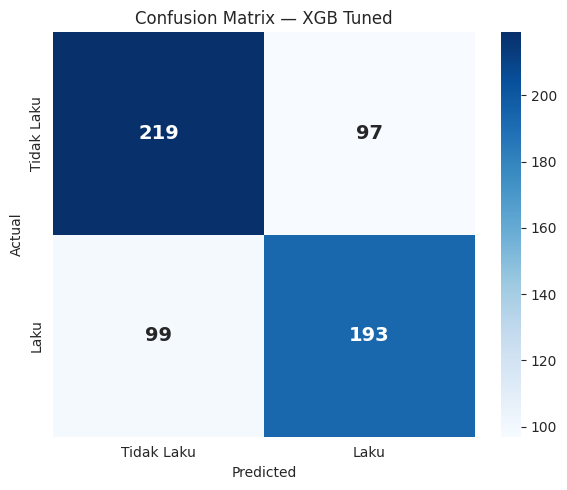

In [ ]:
print(f"\nClassification Report — {BEST_TABULAR_NAME} (calibrated)")
print("=" * 55)
print(classification_report(y_test, BEST_TABULAR_PRED,
                             target_names=["Tidak Laku", "Laku"], zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, BEST_TABULAR_PRED)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Tidak Laku", "Laku"],
            yticklabels=["Tidak Laku", "Laku"],
            annot_kws={"size": 14, "weight": "bold"}, ax=ax)
ax.set_title(f"Confusion Matrix — {BEST_TABULAR_NAME}")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

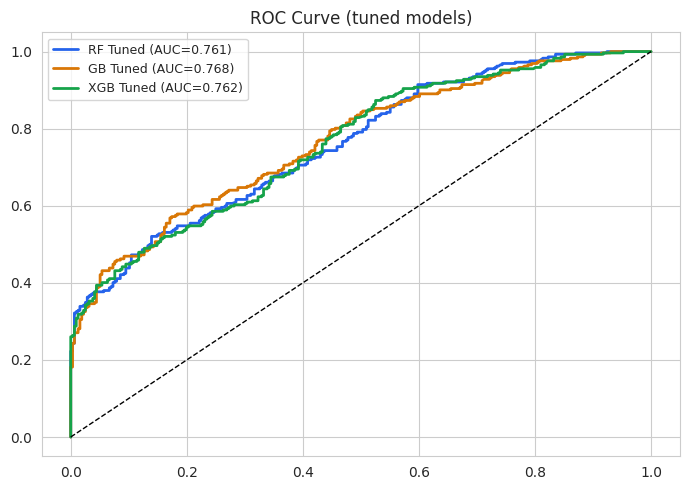

In [ ]:
# ROC Curve
fig, ax = plt.subplots(figsize=(7, 5))
for name, (model, color) in {
    "RF Tuned":  (rf_tuned,  "#2563eb"),
    "GB Tuned":  (gb_tuned,  "#d97706"),
    "XGB Tuned": (xgb_tuned, "#16a34a"),
}.items():
    yp = get_score(model, X_test.values)
    fpr, tpr, _ = roc_curve(y_test, yp)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC={roc_auc_score(y_test, yp):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curve (tuned models)"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

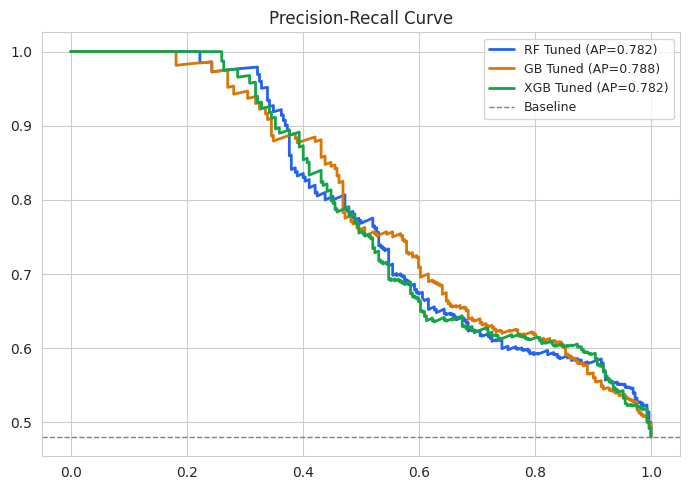

In [ ]:
# Precision-Recall Curve
fig, ax = plt.subplots(figsize=(7, 5))
for name, (model, color) in {
    "RF Tuned":  (rf_tuned,  "#2563eb"),
    "GB Tuned":  (gb_tuned,  "#d97706"),
    "XGB Tuned": (xgb_tuned, "#16a34a"),
}.items():
    yp   = get_score(model, X_test.values)
    prec, rec, _ = precision_recall_curve(y_test, yp)
    ap   = average_precision_score(y_test, yp)
    ax.plot(rec, prec, color=color, lw=2, label=f"{name} (AP={ap:.3f})")
ax.axhline(y_test.mean(), color="gray", linestyle="--", lw=1, label="Baseline")
ax.set_title("Precision-Recall Curve"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

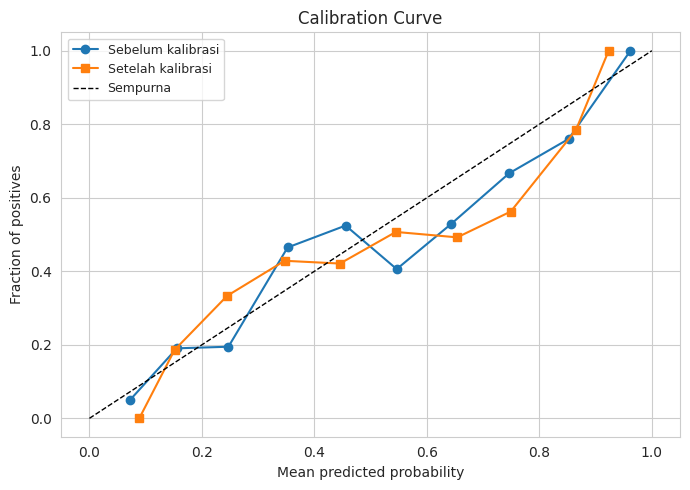

In [ ]:
# Calibration Curve
fig, ax = plt.subplots(figsize=(7, 5))
prob_true_b, prob_pred_b = calibration_curve(
    y_test, BEST_TABULAR_MODEL.predict_proba(X_test.values)[:, 1], n_bins=10)
prob_true_a, prob_pred_a = calibration_curve(y_test, proba_cal, n_bins=10)
ax.plot(prob_pred_b, prob_true_b, marker="o", label="Sebelum kalibrasi")
ax.plot(prob_pred_a, prob_true_a, marker="s", label="Setelah kalibrasi")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Sempurna")
ax.set_title("Calibration Curve")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

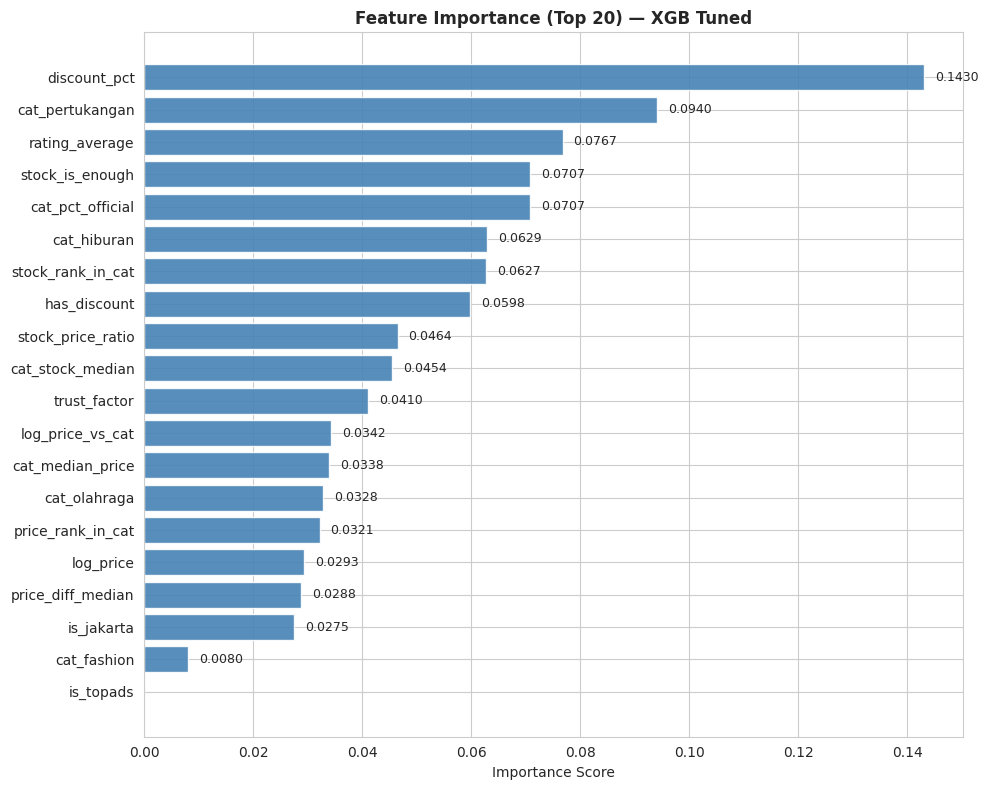


Top 10 fitur:
          feature  importance
     discount_pct    0.143025
  cat_pertukangan    0.094035
   rating_average    0.076740
  stock_is_enough    0.070731
 cat_pct_official    0.070700
      cat_hiburan    0.062875
stock_rank_in_cat    0.062734
     has_discount    0.059778
stock_price_ratio    0.046449
 cat_stock_median    0.045375


In [ ]:
# Feature Importance
importances = model_for_cal.feature_importances_
fi_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20).reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
feat_vals = fi_df["feature"].values[::-1]
imp_vals  = fi_df["importance"].values[::-1]
bars = ax.barh(feat_vals, imp_vals, edgecolor="white", alpha=0.9, color="steelblue")
for bar, val in zip(bars, imp_vals):
    if val > 0.001:
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)
ax.set_title(f"Feature Importance (Top 20) — {BEST_TABULAR_NAME}", fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout(); plt.show()

print("\nTop 10 fitur:")
print(fi_df.head(10).to_string(index=False))


Menghitung SHAP values ...


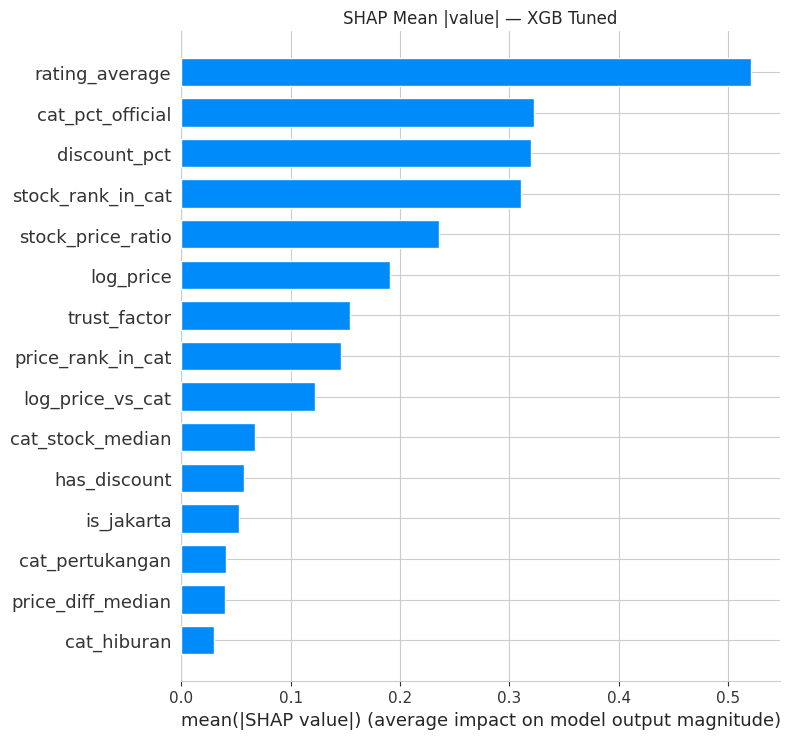

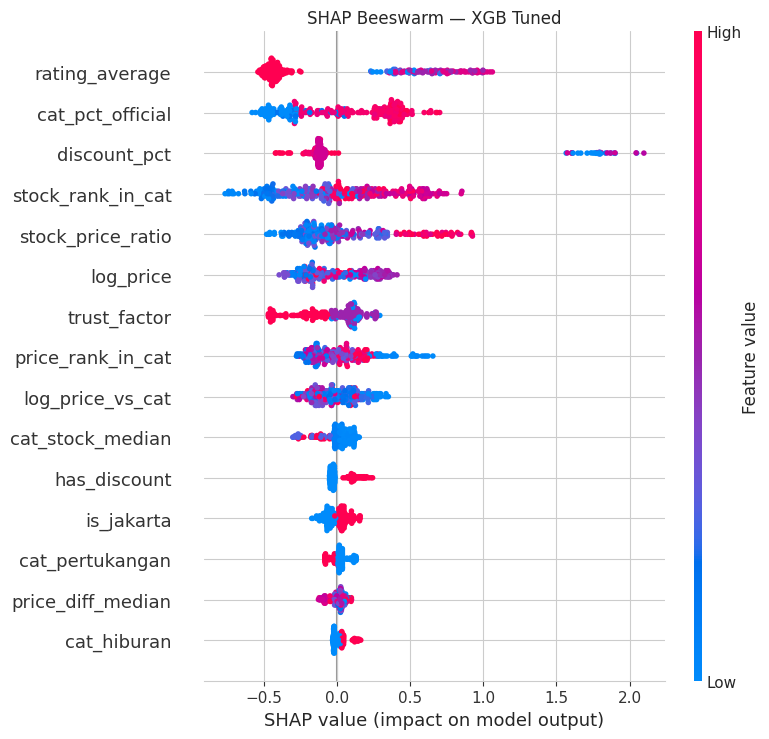

In [ ]:
# SHAP Values
print("\nMenghitung SHAP values ...")
explainer = shap.TreeExplainer(model_for_cal)
X_shap    = X_test.sample(n=min(300, len(X_test)), random_state=RANDOM_STATE)
shap_vals = explainer.shap_values(X_shap.values)
if isinstance(shap_vals, list):
    sv = shap_vals[1]
elif isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
    sv = shap_vals[:, :, 1] if shap_vals.shape[2] > 1 else shap_vals[:, :, 0]
else:
    sv = shap_vals

shap.summary_plot(sv, X_shap, feature_names=FEATURE_COLS,
                  plot_type="bar", max_display=15, show=False)
plt.title(f"SHAP Mean |value| — {BEST_TABULAR_NAME}"); plt.tight_layout(); plt.show()

shap.summary_plot(sv, X_shap, feature_names=FEATURE_COLS, max_display=15, show=False)
plt.title(f"SHAP Beeswarm — {BEST_TABULAR_NAME}"); plt.tight_layout(); plt.show()


In [ ]:
# Cross-Validation Final
print("\n5-Fold Cross Validation (train set) ...")
cv_scores = cross_val_score(
    model_for_cal, X_train.values, y_train.values,
    cv=cv_strat, scoring="roc_auc", n_jobs=-1,
)
gap = abs(BEST_TABULAR_AUC - cv_scores.mean())
print(f"Scores     : {cv_scores.round(3)}")
print(f"Mean ± Std : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Test AUC   : {BEST_TABULAR_AUC:.3f}")
print(f"CV-Test gap: {gap:.3f} ({'OK' if gap < 0.03 else 'Perlu dicermati'})")


5-Fold Cross Validation (train set) ...
Scores     : [0.808 0.782 0.823 0.794 0.787]
Mean ± Std : 0.799 ± 0.015
Test AUC   : 0.760
CV-Test gap: 0.039 (Perlu dicermati)


## 9. INFERENSI

In [ ]:
CATEGORY_ALIASES = {
    "elektronik": "elektronik", "electronic": "elektronik",
    "laptop": "elektronik", "komputer": "elektronik",
    "tv": "elektronik", "kulkas": "elektronik",
    "ac": "elektronik", "mesin cuci": "elektronik",

    "hiburan": "hiburan", "gaming": "hiburan",
    "game": "hiburan", "buku": "hiburan",
    "film": "hiburan", "musik": "hiburan",
    "konsol": "hiburan", "ps5": "hiburan", "xbox": "hiburan",

    "olahraga": "olahraga", "sport": "olahraga",
    "sepatu olahraga": "olahraga", "gym": "olahraga",

    "kecantikan": "kecantikan", "beauty": "kecantikan",
    "kosmetik": "kecantikan", "makeup": "kecantikan",
    "lipstik": "kecantikan", "skincare": "kecantikan",
    "serum": "kecantikan", "moisturizer": "kecantikan",
    "perawatan wajah": "kecantikan", "perawatan tubuh": "kecantikan",

    "makanan_minuman": "makanan_minuman", "makanan": "makanan_minuman",
    "minuman": "makanan_minuman", "snack": "makanan_minuman",
    "food": "makanan_minuman",

    "fashion": "fashion", "baju": "fashion", "kaos": "fashion",
    "celana": "fashion", "dress": "fashion", "kemeja": "fashion",
    "pakaian": "fashion", "baju anak": "fashion",

    "pertukangan": "pertukangan", "perkakas": "pertukangan",
    "alat tukang": "pertukangan", "tools": "pertukangan",
    "obeng": "pertukangan", "bor": "pertukangan",
    "gergaji": "pertukangan", "kunci pas": "pertukangan",
}

# Median rating per kategori — default untuk produk baru tanpa rating
cat_rating_median = (
    df.loc[train_mask]
    .groupby("category_main")["rating_average"]
    .median().to_dict()
)

# Proporsi produk berdiskon per kategori — default untuk inferensi
cat_discount_rate = (
    df.loc[train_mask]
    .groupby("category_main")["has_discount"]
    .mean().to_dict()
)

cat_lookup = cat_stats.merge(
    df.loc[train_mask]
      .groupby("category_main")
      .agg(cat_laku_rate=("is_laku", "mean"))
      .reset_index(),
    on="category_main", how="left",
)

print(f"\nAlias terdefinisi  : {len(CATEGORY_ALIASES)}")
print(f"Kategori tersedia  : {TRAIN_CATEGORIES}")
print()
print(cat_lookup[[
    "category_main", "cat_median_price", "cat_stock_median",
    "cat_sold_median", "cat_laku_rate"
]].to_string(index=False))


Alias terdefinisi  : 52
Kategori tersedia  : ['elektronik', 'hiburan', 'olahraga', 'kecantikan', 'makanan_minuman', 'fashion', 'pertukangan']

  category_main  cat_median_price  cat_stock_median  cat_sold_median  cat_laku_rate
     elektronik         1915000.0              11.0             45.0       0.500000
        fashion          105000.0               3.0              6.0       0.476190
        hiburan          186800.0               8.0             15.5       0.500000
     kecantikan           51163.5              12.0              6.0       0.495000
makanan_minuman           24450.0             328.0            608.0       0.500000
       olahraga          132500.0              88.0            377.5       0.500000
    pertukangan          153125.0              30.0             49.0       0.495312


In [ ]:
def predict_product(
    kategori         : str,
    harga_jual       : float,
    is_official      : int   = 0,
    stock            : float = None,
    is_topads        : int   = 0,
    rating_average   : float = None,
    discounted_price : float = None,
) -> dict:
    """
    Prediksi peluang produk laku di Tokopedia.

    Parameters
    ----------
    kategori         : nama atau alias kategori produk
    harga_jual       : harga normal produk (Rp)
    is_official      : 1 = official store, 0 = bukan
    stock            : jumlah stok (default = median kategori)
    is_topads        : 1 = menggunakan TopAds, 0 = tidak
    rating_average   : rating rata-rata (1-5, default = median kategori)
    discounted_price : harga setelah diskon (None = tidak ada diskon)
    """
    cat_key  = str(kategori).lower().strip()
    cat_name = CATEGORY_ALIASES.get(cat_key)
    if cat_name is None:
        raise ValueError(
            f"Kategori '{kategori}' tidak dikenali. "
            f"Pilihan: {sorted(set(CATEGORY_ALIASES.values()))}"
        )

    row   = cat_lookup[cat_lookup["category_main"] == cat_name]
    stats = row.iloc[0].to_dict() if len(row) > 0 else GLOBAL_FALLBACK.copy()

    cat_med_price = float(stats.get("cat_median_price",  GLOBAL_FALLBACK["cat_median_price"]))
    cat_med_stock = float(stats.get("cat_stock_median",  GLOBAL_FALLBACK["cat_stock_median"]))
    cat_pct_off   = float(stats.get("cat_pct_official",  GLOBAL_FALLBACK["cat_pct_official"]))
    cat_sold_med  = float(stats.get("cat_sold_median",   GLOBAL_FALLBACK["cat_sold_median"]))
    cat_laku_rate = float(stats.get("cat_laku_rate",     df.loc[train_mask, "is_laku"].mean()))

    if stock is None:
        stock = cat_med_stock
    if rating_average is None:
        rating_average = cat_rating_median.get(cat_name, 4.5)

    # Fitur diskon — FIX: sekarang dihitung dari parameter, bukan default 0
    has_discount = 1 if discounted_price is not None else 0
    discount_pct = (
        (harga_jual - discounted_price) / harga_jual
        if discounted_price is not None and harga_jual > 0
        else 0.0
    )
    # Validasi: diskon tidak boleh negatif atau > 100%
    discount_pct = float(np.clip(discount_pct, 0.0, 0.99))

    is_jakarta        = 0
    log_price         = np.log1p(harga_jual)
    log_price_vs_cat  = np.log1p(harga_jual / (cat_med_price + 1.0))
    price_diff_median = log_price - np.log1p(cat_med_price)

    price_sorted      = CATEGORY_TRAIN_VALUES.get("price", {}).get(cat_name, np.array([]))
    stock_sorted      = CATEGORY_TRAIN_VALUES.get("stock", {}).get(cat_name, np.array([]))
    price_rank_in_cat = safe_percentile_rank(harga_jual, price_sorted)
    stock_rank_in_cat = safe_percentile_rank(stock, stock_sorted)

    stock_is_enough   = int(stock > cat_med_stock)
    stock_price_ratio = np.log1p(stock) / (log_price + 1.0)
    trust_factor      = is_official + is_jakarta

    cat_ohe = {f"cat_{c}": int(c == cat_name) for c in TRAIN_CATEGORIES}

    row_dict = {
        "log_price":         log_price,
        "log_price_vs_cat":  log_price_vs_cat,
        "price_rank_in_cat": price_rank_in_cat,
        "price_diff_median": price_diff_median,
        "rating_average":    float(rating_average),
        "has_discount":      has_discount,
        "discount_pct":      discount_pct,
        "stock_rank_in_cat": stock_rank_in_cat,
        "stock_is_enough":   stock_is_enough,
        "stock_price_ratio": stock_price_ratio,
        "is_topads":         int(is_topads),
        "is_jakarta":        is_jakarta,
        "trust_factor":      trust_factor,
        "cat_median_price":  cat_med_price,
        "cat_stock_median":  cat_med_stock,
        "cat_pct_official":  cat_pct_off,
        **cat_ohe,
    }

    X_infer = pd.DataFrame([row_dict]).reindex(columns=FEATURE_COLS, fill_value=0)
    proba   = float(np.clip(BEST_MODEL.predict_proba(X_infer.values)[0, 1], 0.03, 0.97))

    pred = "Laku" if proba >= 0.5 else "Tidak Laku"
    risk = "Rendah" if proba >= 0.65 else "Sedang" if proba >= 0.45 else "Tinggi"

    saran = []
    if harga_jual > cat_med_price * 1.3:
        saran.append(
            f"Harga Rp{harga_jual:,.0f} di atas median Rp{cat_med_price:,.0f}. "
            "Pertimbangkan turunkan harga atau tambah value."
        )
    elif harga_jual < cat_med_price * 0.7:
        saran.append(
            f"Harga Rp{harga_jual:,.0f} jauh di bawah median — pastikan margin masih aman."
        )
    if stock < cat_med_stock * 0.5:
        saran.append(
            f"Stok ({stock:.0f}) di bawah median kategori ({cat_med_stock:.0f}). "
            "Pertimbangkan naikkan stok."
        )
    if has_discount == 0:
        saran.append("Produk tanpa diskon — tambahkan promo harga untuk meningkatkan daya tarik.")
    if is_official == 0:
        saran.append("Official store meningkatkan kepercayaan pembeli.")

    return {
        "kategori_input":    kategori,
        "kategori_resolved": cat_name,
        "prediction":        pred,
        "laku_score":        round(proba * 100, 1),
        "risk_level":        risk,
        "harga_jual":        f"Rp{harga_jual:,.0f}",
        "harga_diskon":      f"Rp{discounted_price:,.0f}" if discounted_price else "Tidak ada",
        "discount_pct":      f"{discount_pct:.1%}" if has_discount else "0%",
        "harga_median_cat":  f"Rp{cat_med_price:,.0f}",
        "cat_sold_median":   f"{cat_sold_med:.0f}",
        "cat_laku_rate":     f"{cat_laku_rate:.1%}",
        "saran_perbaikan":   saran,
    }

print(f"Kategori yang didukung: {sorted(set(CATEGORY_ALIASES.values()))}")

Kategori yang didukung: ['elektronik', 'fashion', 'hiburan', 'kecantikan', 'makanan_minuman', 'olahraga', 'pertukangan']


In [ ]:
# Simulasi prediksi 7 kategori
# Format: (kategori, harga, official, stok, topads, rating, discounted_price)
print("\n" + "=" * 65)
print("SIMULASI PREDIKSI — 7 KATEGORI")
print("=" * 65)

test_cases = [
    ("elektronik",      40_000,    0,  50, 0, None,  32_000),
    ("hiburan",        120_000,    1,  10, 0, 4.5,   None),
    ("olahraga",       250_000,    0,  15, 0, None,  None),
    ("kecantikan",      48_000,    1, 100, 1, 4.7,   38_000),
    ("makanan_minuman", 35_000,    0,  10, 0, None,  None),
    ("fashion",         95_000,    0,  50, 0, 4.3,   79_000),
    ("pertukangan",    125_000,    0,  25, 0, None,  None),
]

for kat, harga, official, stok, topads, rating, disc in test_cases:
    r      = predict_product(kat, harga, official, stok, topads, rating, disc)
    status = "LAKU" if r["prediction"] == "Laku" else "TIDAK LAKU"
    print(f"\n{'─'*65}")
    print(f"Kategori  : {r['kategori_input'].capitalize()} | "
          f"Harga: {r['harga_jual']} → Diskon: {r['harga_diskon']} ({r['discount_pct']})")
    print(f"Median    : {r['harga_median_cat']}")
    print(f"Prediksi  : {status} | Peluang: {r['laku_score']}% | Risiko: {r['risk_level']}")
    print(f"Laku rate : {r['cat_laku_rate']} produk di kategori ini laku")
    for s in r["saran_perbaikan"]:
        print(f"  - {s}")



SIMULASI PREDIKSI — 7 KATEGORI

─────────────────────────────────────────────────────────────────
Kategori  : Elektronik | Harga: Rp40,000 → Diskon: Rp32,000 (20.0%)
Median    : Rp1,915,000
Prediksi  : LAKU | Peluang: 79.2% | Risiko: Rendah
Laku rate : 50.0% produk di kategori ini laku
  - Harga Rp40,000 jauh di bawah median — pastikan margin masih aman.
  - Official store meningkatkan kepercayaan pembeli.

─────────────────────────────────────────────────────────────────
Kategori  : Hiburan | Harga: Rp120,000 → Diskon: Tidak ada (0%)
Median    : Rp186,800
Prediksi  : LAKU | Peluang: 85.9% | Risiko: Rendah
Laku rate : 50.0% produk di kategori ini laku
  - Harga Rp120,000 jauh di bawah median — pastikan margin masih aman.
  - Produk tanpa diskon — tambahkan promo harga untuk meningkatkan daya tarik.

─────────────────────────────────────────────────────────────────
Kategori  : Olahraga | Harga: Rp250,000 → Diskon: Tidak ada (0%)
Median    : Rp132,500
Prediksi  : TIDAK LAKU | Peluang: 4

In [ ]:
# Verifikasi sensitivitas diskon
print("\n" + "=" * 65)
print("VERIFIKASI SENSITIVITAS — PENGARUH DISKON")
print("=" * 65)

discount_tests = [
    # (label,             kat,          harga,    off, stok, topads, rating, disc)
    ("Tanpa diskon",     "kecantikan",  48_000,    1,  100,   1,     4.7,   None),
    ("Diskon 15%",       "kecantikan",  48_000,    1,  100,   1,     4.7,   40_800),
    ("Diskon 30%",       "kecantikan",  48_000,    1,  100,   1,     4.7,   33_600),
    ("Diskon 50%",       "kecantikan",  48_000,    1,  100,   1,     4.7,   24_000),
    ("─"*20,             None,          0,         0,  0,     0,     None,  None),
    ("Tanpa diskon",     "fashion",     95_000,    0,   50,   0,     4.3,   None),
    ("Diskon 20%",       "fashion",     95_000,    0,   50,   0,     4.3,   76_000),
    ("Diskon 40%",       "fashion",     95_000,    0,   50,   0,     4.3,   57_000),
    ("─"*20,             None,          0,         0,  0,     0,     None,  None),
    ("Tanpa diskon",     "elektronik",  1_500_000, 1,   10,   0,     4.8,   None),
    ("Diskon 10%",       "elektronik",  1_500_000, 1,   10,   0,     4.8,   1_350_000),
    ("Diskon 20%",       "elektronik",  1_500_000, 1,   10,   0,     4.8,   1_200_000),
]

for label, kat, harga, off, stok, topads, rating, disc in discount_tests:
    if kat is None:
        print(f"\n{label}")
        continue
    r      = predict_product(kat, harga, off, stok, topads, rating, disc)
    status = "LAKU" if r["prediction"] == "Laku" else "TIDAK LAKU"
    disc_str = r["discount_pct"] if disc else "0%"
    print(f"  {label:<15} → {status} | Peluang: {r['laku_score']}% | Diskon: {disc_str}")

print(f"\nModel final : {BEST_TABULAR_NAME} (calibrated, sigmoid)")
print(f"Test AUC    : {BEST_TABULAR_AUC:.3f}")
print(f"Total fitur : {len(FEATURE_COLS)}")


VERIFIKASI SENSITIVITAS — PENGARUH DISKON
  Tanpa diskon    → LAKU | Peluang: 89.9% | Diskon: 0%
  Diskon 15%      → LAKU | Peluang: 89.4% | Diskon: 15.0%
  Diskon 30%      → LAKU | Peluang: 89.6% | Diskon: 30.0%
  Diskon 50%      → LAKU | Peluang: 89.6% | Diskon: 50.0%

────────────────────
  Tanpa diskon    → LAKU | Peluang: 85.7% | Diskon: 0%
  Diskon 20%      → LAKU | Peluang: 84.2% | Diskon: 20.0%
  Diskon 40%      → LAKU | Peluang: 85.5% | Diskon: 40.0%

────────────────────
  Tanpa diskon    → LAKU | Peluang: 71.1% | Diskon: 0%
  Diskon 10%      → LAKU | Peluang: 72.9% | Diskon: 10.0%
  Diskon 20%      → LAKU | Peluang: 70.6% | Diskon: 20.0%

Model final : XGB Tuned (calibrated, sigmoid)
Test AUC    : 0.760
Total fitur : 23


## 10. EKSPOR ARTEFAK

In [ ]:
export_dir = Path(MODEL_DIR)
export_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(BEST_MODEL, export_dir / "tokped_classifier.pkl")
print("\ntokped_classifier.pkl   — model terkalibrasi (sigmoid)")

with open(export_dir / "feature_cols.json", "w", encoding="utf-8") as f:
    json.dump(FEATURE_COLS, f, ensure_ascii=False, indent=2)
print("feature_cols.json")

with open(export_dir / "category_levels.json", "w", encoding="utf-8") as f:
    json.dump(TRAIN_CATEGORIES, f, ensure_ascii=False, indent=2)
print("category_levels.json")

cat_lookup.to_json(
    export_dir / "category_stats.json",
    orient="records", force_ascii=False, indent=2,
)
print("category_stats.json")

with open(export_dir / "category_aliases.json", "w", encoding="utf-8") as f:
    json.dump(CATEGORY_ALIASES, f, ensure_ascii=False, indent=2)
print("category_aliases.json")

with open(export_dir / "cat_rating_median.json", "w", encoding="utf-8") as f:
    json.dump(cat_rating_median, f, ensure_ascii=False, indent=2)
print("cat_rating_median.json")

with open(export_dir / "cat_discount_rate.json", "w", encoding="utf-8") as f:
    json.dump(cat_discount_rate, f, ensure_ascii=False, indent=2)
print("cat_discount_rate.json")

meta = {
    "label_rule":            "is_laku = 1 jika count_sold > cat_sold_median (train only)",
    "aggregation_level":     "category_main",
    "train_only_stats":      True,
    "train_categories":      TRAIN_CATEGORIES,
    "supported_categories":  TRAIN_CATEGORIES,
    "best_model":            BEST_TABULAR_NAME,
    "calibration":           "sigmoid (CalibratedClassifierCV, cv=prefit, test_size=0.3)",
    "test_auc":              round(BEST_TABULAR_AUC, 4),
    "random_state":          RANDOM_STATE,
    "feature_cols":          FEATURE_COLS,
    "n_features":            len(FEATURE_COLS),
    "removed_features":      ["is_official — digabung ke trust_factor"],
    "added_features":        ["rating_average", "is_topads", "has_discount", "discount_pct"],
    "known_limitations": {
        "pertukangan":   "800 baris sintetik dengan distribusi lognormal; cat_sold_median=49",
        "is_topads":     "Hanya ~50 sampel topads di dataset; sinyal lemah",
        "cv_test_gap":   "Gap ~0.04 disebabkan distribusi sintetik vs data asli",
        "auc_ceiling":   "AUC ~0.76 adalah batas wajar untuk fitur tabular tanpa data review/ranking",
    },
}
with open(export_dir / "model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print("model_metadata.json")

archive_path = shutil.make_archive(str(export_dir), "zip", root_dir=export_dir)
print(f"\nZip dibuat: {archive_path}")

try:
    from google.colab import files
    files.download(archive_path)
except Exception as exc:
    print("Download otomatis dilewati:", exc)

print(f"\nSemua artefak tersimpan di: {export_dir}")
print(f"Model siap digunakan. Test AUC: {BEST_TABULAR_AUC:.3f}")


tokped_classifier.pkl   — model terkalibrasi (sigmoid)
feature_cols.json
category_levels.json
category_stats.json
category_aliases.json
cat_rating_median.json
cat_discount_rate.json
model_metadata.json

Zip dibuat: /content/model_artifact.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Semua artefak tersimpan di: /content/model_artifact
Model siap digunakan. Test AUC: 0.760
